<a href="https://colab.research.google.com/github/calelo3232/Orbital-Modeling/blob/main/436project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

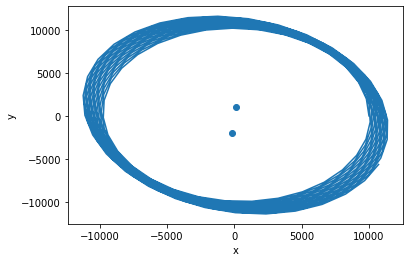

In [ ]:
G = 6.67 * 10**(-11)
m1 = 1.989 * 10**(30)
m2 = 1.989 * 10**(20)
m = 45000
B = np.array([100,1000]) # location of star B
C = np.array([-200,-2000]) # location of star C
#func1 = lambda t,y: np.array([y[1],G/m2 * m1 * np.linalg.norm(y[0] - B) / np.linalg.norm(y - B)**3 - y[0]])
#func2 = lambda t,x: np.array([x[1],G/m2 * m1 * np.linalg.norm(x[0] - B) / np.linalg.norm(x - B)**3 - x[0]])
func1 = lambda t,y: np.array([y[1],G/m * (m1 * np.linalg.norm(y[0] - B[1]) / np.linalg.norm(y - B)**3 + m2 * np.linalg.norm(y[0] - C[1]) / np.linalg.norm(y - C)**3) - y[0]])
func2 = lambda t,x: np.array([x[1],G/m * (m1 * np.linalg.norm(x[0] - B[0]) / np.linalg.norm(x - B)**3 + m2 * np.linalg.norm(x[0] - C[0]) / np.linalg.norm(x - C)**3) - x[0]])
x_0 = np.array([10000,0]) # initial conditions
y_0 = np.array([0,10000]) # initial conditions
time1 = np.linspace(0,100,500)
sol1 = solve_ivp(func1,(0,100),x_0,t_eval=time1) # solve ode system
sol2 = solve_ivp(func2,(0,100),y_0,t_eval=time1) # solve ode system
plt.scatter([B[0],C[0]], [B[1],C[1]])
plt.plot(sol1.y[0], sol2.y[0]) # plot numerical solutions
plt.xlabel('x')
plt.ylabel('y')
plt.show()

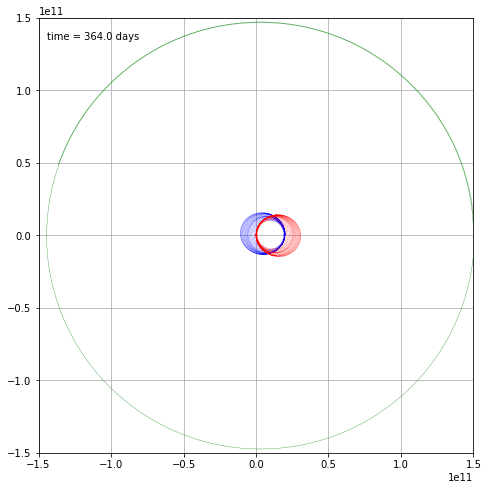

In [ ]:
#feel free to improve
#TODO: scale this up to an arbitrary number of orbiting bodies

# physical constants
G = 6.67408e-11  # m^3 kg^-1 s^-2
M1 = 1.989e30  # kg
M2 = 1.989e30  # kg
M3 = 5.972e24  # kg

#M3 = 1

# initial conditions
x1_0 = 2.0e10  # m
y1_0 = 1.0e9  # m
x2_0 = 0.0  # m
y2_0 = 0.0  # m
x3_0 = 1.5e11  # m
y3_0 = 0.0  # m
vx1_0 = 0.0  # m s^-1
vy1_0 = 67000.0  # m s^-1
vx2_0 = 0.0  # m s^-1
vy2_0 = -67000.0  # m s^-1
vx3_0 = 0.0  # m s^-1
vy3_0 = 45000.0  # m s^-1

# time interval
t_0 = 0.0  # s
t_f = 365.0 * 24.0 * 3600.0 # s

# time step
dt = 3600 *24 # s

# initial conditions
y_0 = np.array([x1_0, y1_0, x2_0, y2_0, x3_0, y3_0, vx1_0, vy1_0, vx2_0, vy2_0, vx3_0, vy3_0])


def f(t, y):
    """
    function to integrate
    :param t: time
    :param y: variables
    :return: derivatives of the variables
    """
    x1 = y[0]
    y1 = y[1]
    x2 = y[2]
    y2 = y[3]
    x3 = y[4]
    y3 = y[5]
    vx1 = y[6]
    vy1 = y[7]
    vx2 = y[8]
    vy2 = y[9]
    vx3 = y[10]
    vy3 = y[11]

    # calculate distances
    r12 = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
    r13 = np.sqrt((x1 - x3) ** 2 + (y1 - y3) ** 2)
    r23 = np.sqrt((x2 - x3) ** 2 + (y2 - y3) ** 2)

    # calculate accelerations
    ax1 = -G * M2 * (x1 - x2) / r12 ** 3 - G * M3 * (x1 - x3) / r13 ** 3
    ay1 = -G * M2 * (y1 - y2) / r12 ** 3 - G * M3 * (y1 - y3) / r13 ** 3
    ax2 = -G * M1 * (x2 - x1) / r12 ** 3 - G * M3 * (x2 - x3) / r23 ** 3
    ay2 = -G * M1 * (y2 - y1) / r12 ** 3 - G * M3 * (y2 - y3) / r23 ** 3
    ax3 = -G * M1 * (x3 - x1) / r13 ** 3 - G * M2 * (x3 - x2) / r23 ** 3
    ay3 = -G * M1 * (y3 - y1) / r13 ** 3 - G * M2 * (y3 - y2) / r23 ** 3

    # return derivatives
    return np.array([vx1, vy1, vx2, vy2, vx3, vy3, ax1, ay1, ax2, ay2, ax3, ay3])


# solve ODE
sol = solve_ivp(f, [t_0, t_f], y_0, method='RK45', t_eval=np.arange(t_0, t_f, dt))

# extract solution
t = sol.t
x1 = sol.y[0, :]
y1 = sol.y[1, :]
x2 = sol.y[2, :]
y2 = sol.y[3, :]
x3 = sol.y[4, :]
y3 = sol.y[5, :]

# create figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, aspect='equal', autoscale_on=False, xlim=(-1.5e11, 1.5e11), ylim=(-1.5e11, 1.5e11))
ax.grid()

# create plot
line1, = ax.plot([], [], 'g', lw=0.2, color='blue')
line2, = ax.plot([], [], 'g', lw=0.2, color='red')
line3, = ax.plot([], [], 'g', lw=0.3, color='green')
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)


def init():
    """
    initialize animation
    :return: line objects
    """
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    time_text.set_text('')
    return line1, line2, line3, time_text


def animate(i):
    """
    animate
    :param i: frame
    :return: line objects
    """
    line1.set_data(x1[:i], y1[:i])
    line2.set_data(x2[:i], y2[:i])
    line3.set_data(x3[:i], y3[:i])
    time_text.set_text('time = %.1f days' % (t[i] / (24.0 * 3600.0)))
    return line1, line2, line3, time_text


# run animation
ani = FuncAnimation(fig, animate, frames=len(t), interval=10, blit=True, init_func=init)

ani.save('orbit.mp4', fps=24, extra_args=['-vcodec', 'libx264'])

HTML(ani.to_html5_video())

#The two suns keep falling into each other. I think it might be caused by error in the approximation (decreasing dt makes it take more days to collapse)

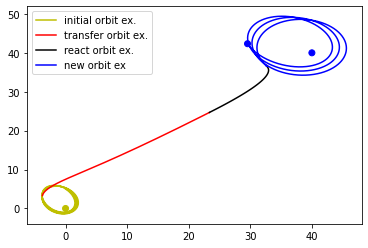

In [ ]:
#This is code showing the transfer of orbits-ish between two fixed bodies in space. I was working with it to practice working with the differential equations
#The binary star system is interesting, but I think those are fairly accurately modelled as a single star system, because in order to have a stable orbit, an orbiting planet would need to have a far enough distance to where the separate gravitational forces from the two stars are essentially equal.
#My next goal is to extend the idea to swapping orbits between moving bodies in space. We can choose to model this by trying to build an orbitting system, or by creating relative orbits, modelled as ellipses, instead of calculating at each step

#These are the positions for the two fixed bodies
st = np.array([0,0,40,40])

#The masses, A is our moving body, while B and C are fixed bodies
mA = 1
mB = 40
mC = 40

#Our update formula
def ode_1(t,y):
  #Does not have thrusting force defined, so that needs to be defined before calling the function
  distance = np.linalg.norm(np.array([y[0] - st[0],y[2] - st[1]])) ** 3
  distance_1 = np.linalg.norm(np.array([y[0]-st[2],y[2]-st[3]])) ** 3
  g = -9.8
  return np.array([y[1],g/mA * (mB * (y[0]-st[0])/distance + mC * (y[0]-st[2])/distance_1) + Fx/mA,y[3],(mB * (y[2]-st[1])/distance + mC * (y[2]-st[3])/distance_1) * g/mA + Fy/mA])

#This is an example of using a fixed point system with multiple stages of movement

#Defining forces for a start position (basically, a bad orbit)
Fx = 0
Fy = 0

#Our time period
t = (0,10)

#Where we start [Ax,Ax',Ay,Ay']
start_1 = np.array([0,5,5,-5])

#Saving our solution
sol = solve_ivp(ode_1,t,start_1,max_step = 0.01)

#A second start, where we add thrust to switch between planets. Starts from the end of the previous array
t = (0,2)
Fx = 10
Fy = 10
start_1 = np.array([sol.y[0][-1],sol.y[1][-1],sol.y[2][-1],sol.y[3][-1]])
sol_1 = solve_ivp(ode_1,t,start_1,max_step = 0.01)

#A third stage, reversing our thrust so we don't pass the second body
t = (0,1)
Fx = -30
Fy = -15
start_1 = np.array([sol_1.y[0][-1],sol_1.y[1][-1],sol_1.y[2][-1],sol_1.y[3][-1]])
sol_2 = solve_ivp(ode_1,t,start_1,max_step = 0.01)

#Final stage, eliminating thrust and entering an orbit (a pretty bad one)
t = (0,20)
Fx = 0
Fy = 0
start_1 = np.array([sol_2.y[0][-1],sol_2.y[1][-1],sol_2.y[2][-1],sol_2.y[3][-1]])
sol_3 = solve_ivp(ode_1,t,start_1,max_step = 0.01)


plt.plot(sol.y[0],sol.y[2],color = 'y',label = 'initial orbit ex.')
plt.plot(sol_1.y[0],sol_1.y[2],color = 'r',label = 'transfer orbit ex.')
plt.plot(sol_2.y[0],sol_2.y[2],color = 'k',label = 'react orbit ex.')
plt.plot(sol_3.y[0],sol_3.y[2],color = 'b',label = 'new orbit ex')

plt.scatter([st[0],st[2],sol_3.y[0][-1]],[st[1],st[3],sol_3.y[2][-1]],c = ['y','b','b'])
plt.legend()
plt.show()

#Obviously, this is not an accurate model. The planets aren't at fixed places,
#and we wouldn't have a ship equal to 1/40th the mass of a planet, but it is good
#to show that a roughly stable system can be created